# LAT Workshop Tutorial #1: Sensitivity Curves, SNR, Inner Products, Likelihoods

In [2]:
# # if running in google colab
# !pip install eryn lisaanalysistools

In [3]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from lisatools.utils.constants import *
from copy import deepcopy  # can be useful

In the first tutorial, we will learn how to use `lisatools` to generate sensitivity curves for LISA. With this information, we will then compute inner products, signal-to-noise ratios (SNR), and Likelihoods for a basic example source. 

## Task 1: Plotting and comparing sensitivity curves.

Calculate and plot the **sky-averaged** LISA sensitivity function ([LISASens](https://mikekatz04.github.io/LISAanalysistools/build/html/user/sensitivity.html#lisatools.sensitivity.LISASens)) in the characteristic strain representation. Compare the **model** used for the LDC2A (or Sangria) dataset to the Science Requirements Document version for the sensitivity curves (`scirdv1`).

Useful documentation:
* [get_available_default_lisa_models](https://mikekatz04.github.io/LISAanalysistools/build/html/user/main.html#lisatools.detector.get_available_default_lisa_models)
* [get_stock_sensitivity_options](https://mikekatz04.github.io/LISAanalysistools/build/html/user/sensitivity.html#lisatools.sensitivity.get_stock_sensitivity_options)
* [get_sensitivity](https://mikekatz04.github.io/LISAanalysistools/build/html/user/sensitivity.html#lisatools.sensitivity.get_sensitivity)
* [LISASens](https://mikekatz04.github.io/LISAanalysistools/build/html/user/sensitivity.html#lisatools.sensitivity.LISASens)

全天平均 (Sky-averaged)：引力波从不同方向传来的响应不同，这里要求你取一个统计平均值，给出一个普适的灵敏度底噪。

特征应变表征 (Characteristic Strain)：这是引力波领域的一种常用单位（记作$h_c$）。它在log-log图上能直观地显示出信号是否能从背景噪声中“跳出来”。

模型对比：

- `scirdv1`：这是 LISA 的“官方理想值”（科学需求文档版本），代表了探测器理论上应该达到的最强听力。

- `LDC2A(Sangria)`：这是“实战模拟值”。它比理想值更复杂，因为里面塞进了银河系白矮星双星背景 (Galactic Forground)。你会发现它在某些频段比理想值要“脏”不少。

In [4]:
# useful imports
from lisatools.sensitivity import LISASens, get_sensitivity, get_stock_sensitivity_options
import lisatools.detector as lisa_models

In [5]:
get_stock_sensitivity_options()

['X1TDISens',
 'Y1TDISens',
 'Z1TDISens',
 'XY1TDISens',
 'YZ1TDISens',
 'ZX1TDISens',
 'A1TDISens',
 'E1TDISens',
 'T1TDISens',
 'X2TDISens',
 'Y2TDISens',
 'Z2TDISens',
 'XY2TDISens',
 'YZ2TDISens',
 'ZX2TDISens',
 'LISASens',
 'CornishLISASens',
 'FlatPSDFunction']

In [6]:
lisa_models.sangria

LISAModel(Soms_d=6.241e-23, Sa_a=5.76e-30, orbits=<lisatools.detector.DefaultOrbits object at 0x7542f7d83e90>, name='sangria')

In [7]:
lisa_models.scirdv1

LISAModel(Soms_d=2.25e-22, Sa_a=9e-30, orbits=<lisatools.detector.DefaultOrbits object at 0x7542f8c886e0>, name='scirdv1')

以上给出的是一些硬件参数。

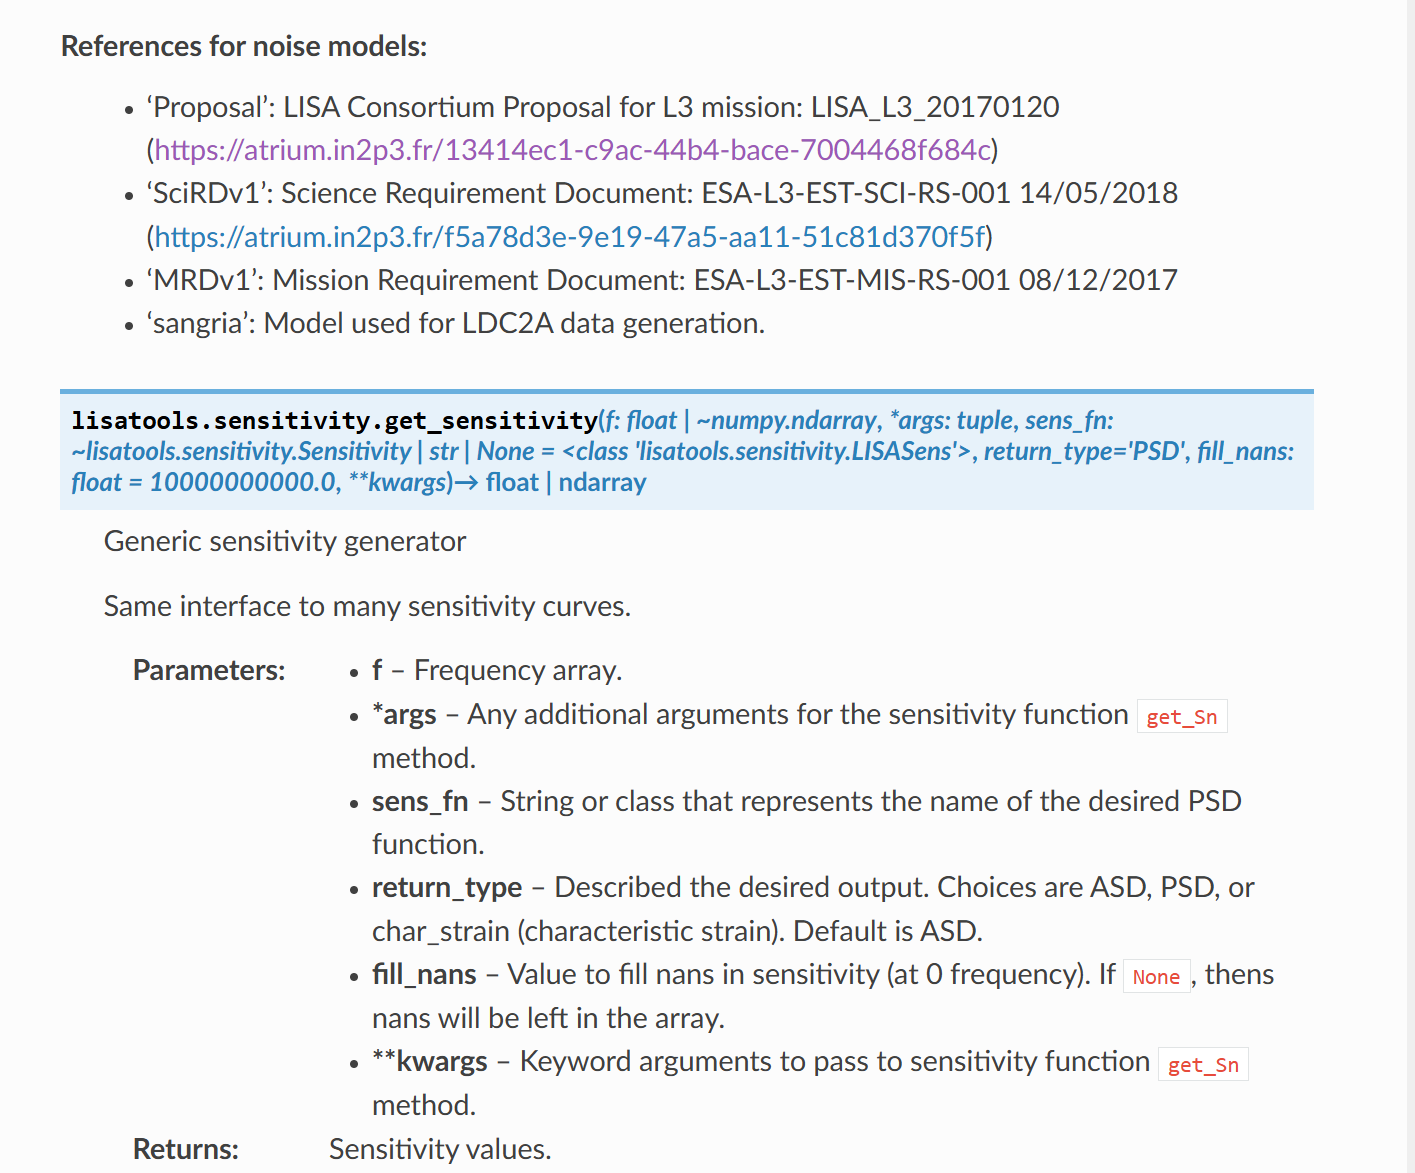
图中的设置，

f (Frequency array)：这是你告诉它你想看哪个频段。通常传一个NumPy数组

sens_fn：这里填入字符串，比如 'scirdv1' 或 'sangria'。这决定了你调用的是哪份“听力图”。

return_type (核心重点)：
默认是 ASD（幅度谱密度）。要求使用 char_strain（特征应变）。所以调用时你必须加上 return_type='char_strain'。

在引力波数据分析中，这两个词描述的是噪声在频域的分布：PSD (Power Spectral Density，功率谱密度)：符号通常写作 $S_n(f)$。物理意义：代表单位频率内的噪声功率。单位：$\text{Hz}^{-1}$ (或者更严谨说是 $\text{strain}^2/\text{Hz}$)。

ASD (Amplitude Spectral Density，幅度谱密度)：公式：$\text{ASD} = \sqrt{\text{PSD}}$。物理意义：PSD 的开方。单位：$\text{Hz}^{-1/2}$ (即 $\text{strain}/\sqrt{\text{Hz}}$)。它的好处是量纲与引力波应变 $h(f)$ 一致，在图上可以直接对比信号幅度。

注意：任务要求使用 char_strain (特征应变 $h_c$)。公式关系为：$h_c = \sqrt{f \cdot S_n(f)}$。它描述的是单位对数频率区间内的噪声贡献。
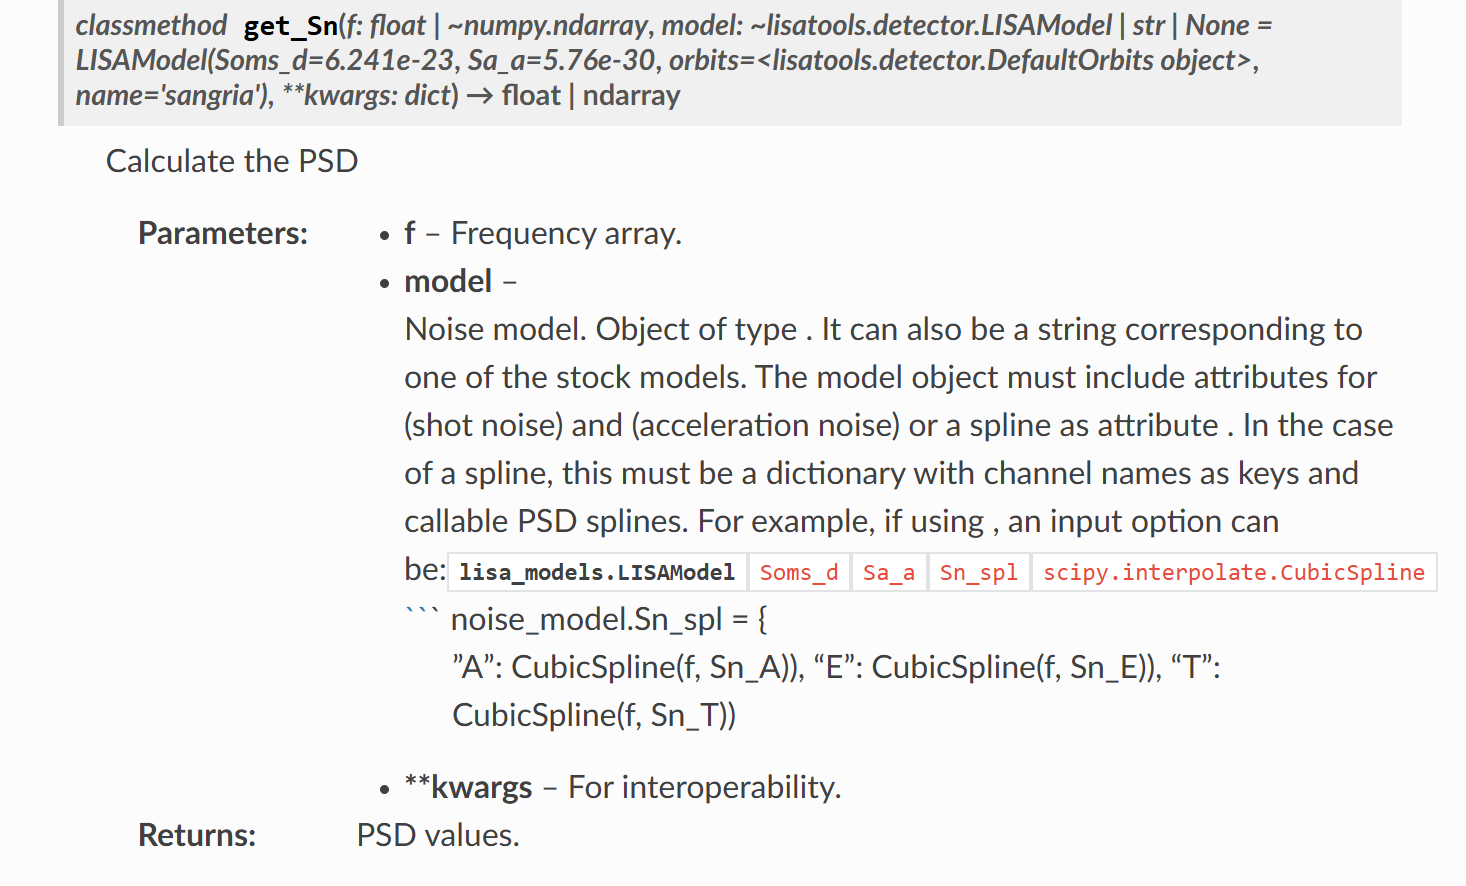
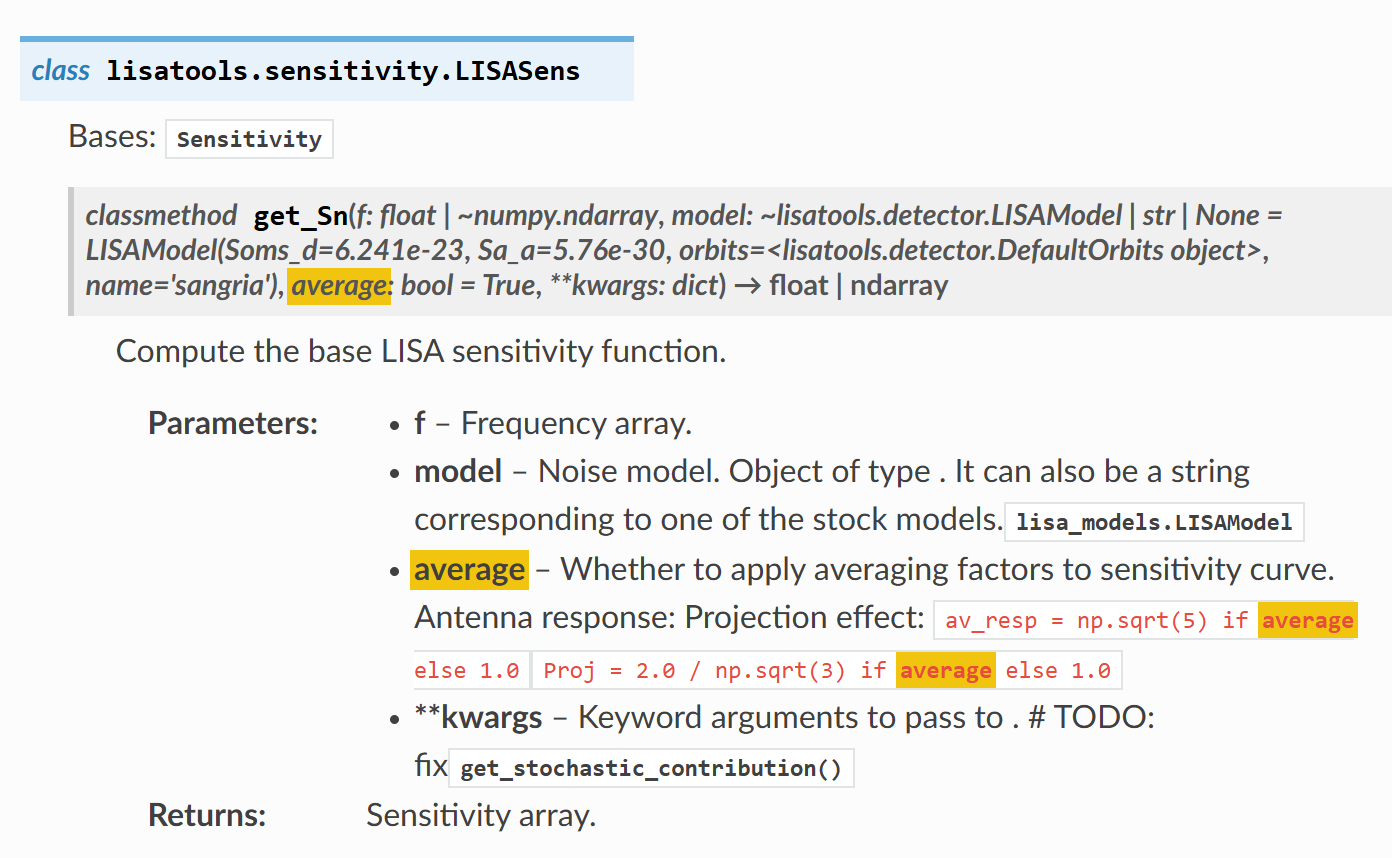

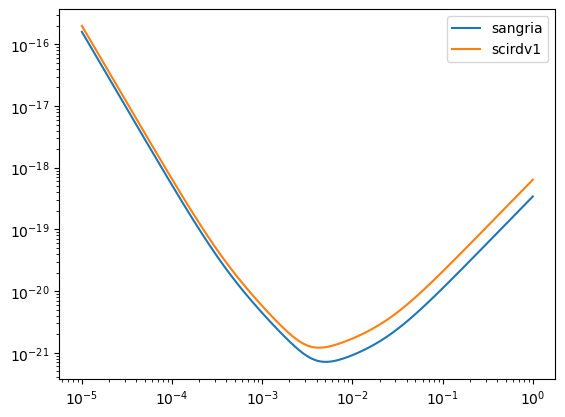

In [8]:
f=np.logspace(-5,0,1000)
hc1=get_sensitivity(f,sens_fn=LISASens,average=True,model=lisa_models.sangria,return_type='char_strain')
plt.loglog(f, hc1, label="sangria")
f=np.logspace(-5,0,1000)
hc2=get_sensitivity(f,sens_fn=LISASens,average=True,model=lisa_models.scirdv1,return_type='char_strain')
plt.loglog(f, hc2, label="scirdv1")
plt.legend()

scirdv1是科学要求的最低标准。所以其灵敏度曲线是最不灵敏的。对于sangria更偏向于真实的曲线，所以灵敏度稍微高一点，图中全频段的灵敏度都高于scirdv1，噪声更小。

这条灵敏度曲线描述了 LISA 探测器本身在各个频率下的噪声水平（特征应变 $h_c$） 。一般而言，低于噪声的单脉冲信号就没救了。因为无法区分是噪声还是信号。所以在曲线上方是可以听到的信号。但是是否真的能听清楚，需要用SNR（信噪比）来衡量。

低于曲线的区域，不完全没有救。
即使瞬时信号强度低于噪声，但由于信号是相干的（有规律），而噪声是随机的，通过长时间的积分累计，信号的特征会逐渐显现。这就像在嘈杂的派对上，你虽然听不清某个人在说什么，但如果你知道他说话的节奏和基调，听得时间足够长，你就能把他的话“扣”出来 。

### Question 1

How do you expect the difference in sensitivity curve models to affect LISA observations? Consider what higher noise at lower or high frequencies will do to our different source classes. 

灵敏曲线模型直接决定了最后灵敏曲线的样子。灵敏曲线又最终影响了SNR的计算，也就决定了一个信号到底是否真的可以被听清。如果在低频率有更高的噪声。超大质量黑洞双星的旋进阶段就在这个频段。如果低频噪声太高，我们就无法提前预警这些黑洞的碰撞，甚至完全看不见它们。

高频率的更高的噪声，会截断双星合并的频率，也就是说在双星合并过程的前期可能会探测到。但是随着双星合并的距离变小，频率变大，就听不到了。丢失合体瞬间的信号

### Question 2

We have asked you to compute the sky-averaged sensitivity curves. What does that mean? Can you determine, without looking at the documentation what the total sky-averaging factor is?

sky-averaged灵敏曲线表示全天球平均的灵敏曲线，探测灵敏曲线是特定的最灵敏方向给出的。但是实际上，这个信号是全天球来的，所以其功率需要除一个数1/5，这样因子为$\sqrt{5}$。LISA 这种 60° 夹角的干涉仪，其全天球平均的响应功率大约只有最优方向功率的 1/5。

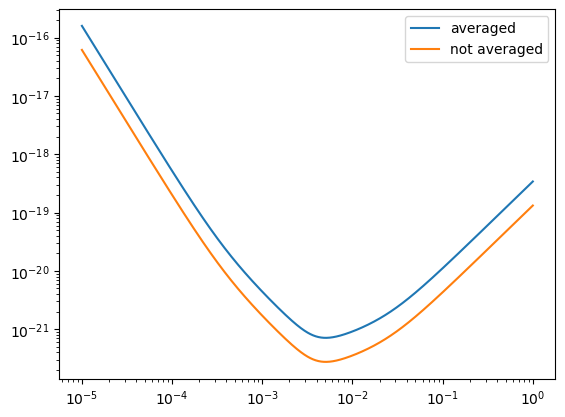

In [9]:
f=np.logspace(-5,0,1000)
hc1=get_sensitivity(f,sens_fn=LISASens,average=True,model=lisa_models.sangria,return_type='char_strain')
plt.loglog(f, hc1, label="averaged")
f=np.logspace(-5,0,1000)
hc2=get_sensitivity(f,sens_fn=LISASens,average=False,model=lisa_models.sangria,return_type='char_strain')
plt.loglog(f, hc2, label="not averaged")
plt.legend()


Now we are going to put our sensitivity information into a [SensitivityMatrix](https://mikekatz04.github.io/LISAanalysistools/build/html/user/sensitivity.html#lisatools.sensitivity.SensitivityMatrix). Build a two-channel (with no cross-channels) sensitivity matrix where both channels' sensitivity are governed by the [LISASens](https://mikekatz04.github.io/LISAanalysistools/build/html/user/sensitivity.html#lisatools.sensitivity.LISASens) sensitivity function.

Useful documentation:
* [SensitivityMatrix](https://mikekatz04.github.io/LISAanalysistools/build/html/user/sensitivity.html#lisatools.sensitivity.SensitivityMatrix)

We will add one extra useful piece of information into here: an estimated Galactic（银河系） foreground noise to include in the sensitivity. This is important when performing LISA data analysis.

The default foreground function is `FittedHyperbolicTangentGalacticForeground`. It takes one parameter: observation time in seconds. Use the documentation of the sensitivity function and the stochastic function to determine how to pass this information with the abstracted setup in `lisatools`. 

Useful documentation:
* [LISASens](https://mikekatz04.github.io/LISAanalysistools/build/html/user/sensitivity.html#lisatools.sensitivity.LISASens)
* [FittedHyperbolicTangentGalacticForeground](https://mikekatz04.github.io/LISAanalysistools/build/html/user/stochastic.html#lisatools.stochastic.FittedHyperbolicTangentGalacticForeground)

LISA 是个三角形，有三条激光臂。按照最原始的物理输出（XYZ 通道），它们确实是高度相关的 3 个通道。但在实际处理中，我们会进行 TDI（时间延迟干涉测量） 的线性组合，把它们转换成 A, E, T 三个正交通道：

A 和 E (Science Channels)：这是引力波信号最强的两个通道。绝大多数的科学信息（比如你以后要拟合的黑洞参数）都藏在这两个通道里。

T (Null Channel)：这个通道对引力波信号不敏感，主要用来监测仪器自身的噪声。


The sensitivity matrix is designed to house sensitivity information that will enter into the Likelihood function. It is a matrix because the 3 channels in LISA will be correlated. Therefore, in XYZ channels, this is a 3x3 matrix that includes correlated cross-terms between the channels. When working with AET channels (uncorrelated in idealized noise situations), then the sensitivity matrix will be an array of length 2 for AE or 3 for AET. 

In [10]:
from lisatools.sensitivity import SensitivityMatrix, LISASens, A1TDISens,E1TDISens,T1TDISens

In [11]:
sens_kwargs = {"stochastic_params":(1.0 * YRSID_SI,)}
#sens_kwargs = dict(stochastic_params=(1.0 * YRSID_SI,))上面的两种写法是等价的。
sens_mat = SensitivityMatrix(f, [A1TDISens,E1TDISens], **sens_kwargs)

这个传递，看说明书极其复杂。。。。

首先先找到SensitivityMatrix
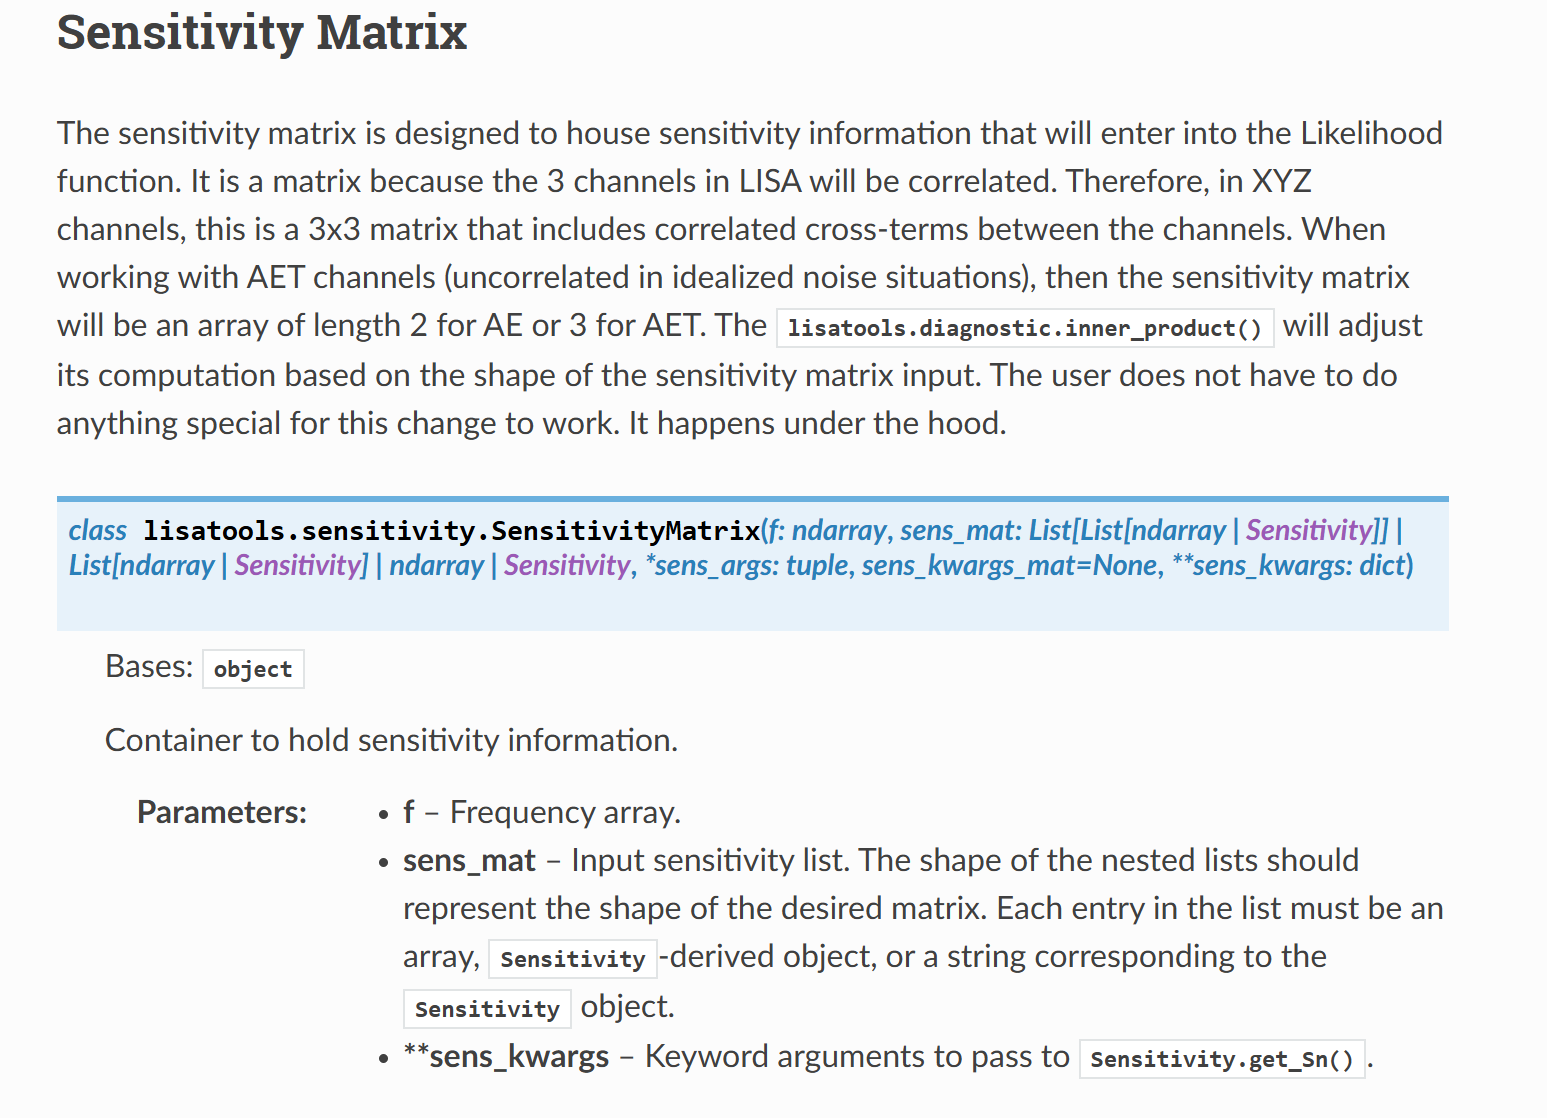
SensitivityMatrix，可以给出概然函数的灵敏度矩阵，我们这里只关心2个矩阵，也就是A和E通道。（LISA 是个三角形，有三条激光臂。按照最原始的物理输出（XYZ 通道），它们确实是高度相关的 3 个通道。但在实际处理中，我们会进行 TDI（时间延迟干涉测量） 的线性组合**不采用这种TDI，激光干涉的扰动就会给出很大的噪声扰动。就不能用了，探测不到GWs了**，把它们转换成 A, E, T 三个正交通道。）

是用于储存Container to hold sensitivity information.

我们需要考虑银河系前景噪声加到灵敏曲线上。这也是为了长期的时间积分，获得微弱的GWs。注意到图中，似乎没有添加的部分，我们看到**sens_kwargs – Keyword arguments to pass to ``Sensitivity.get_Sn()``.

这样促使我们去寻找``Sensitivity.get_Sn()``，
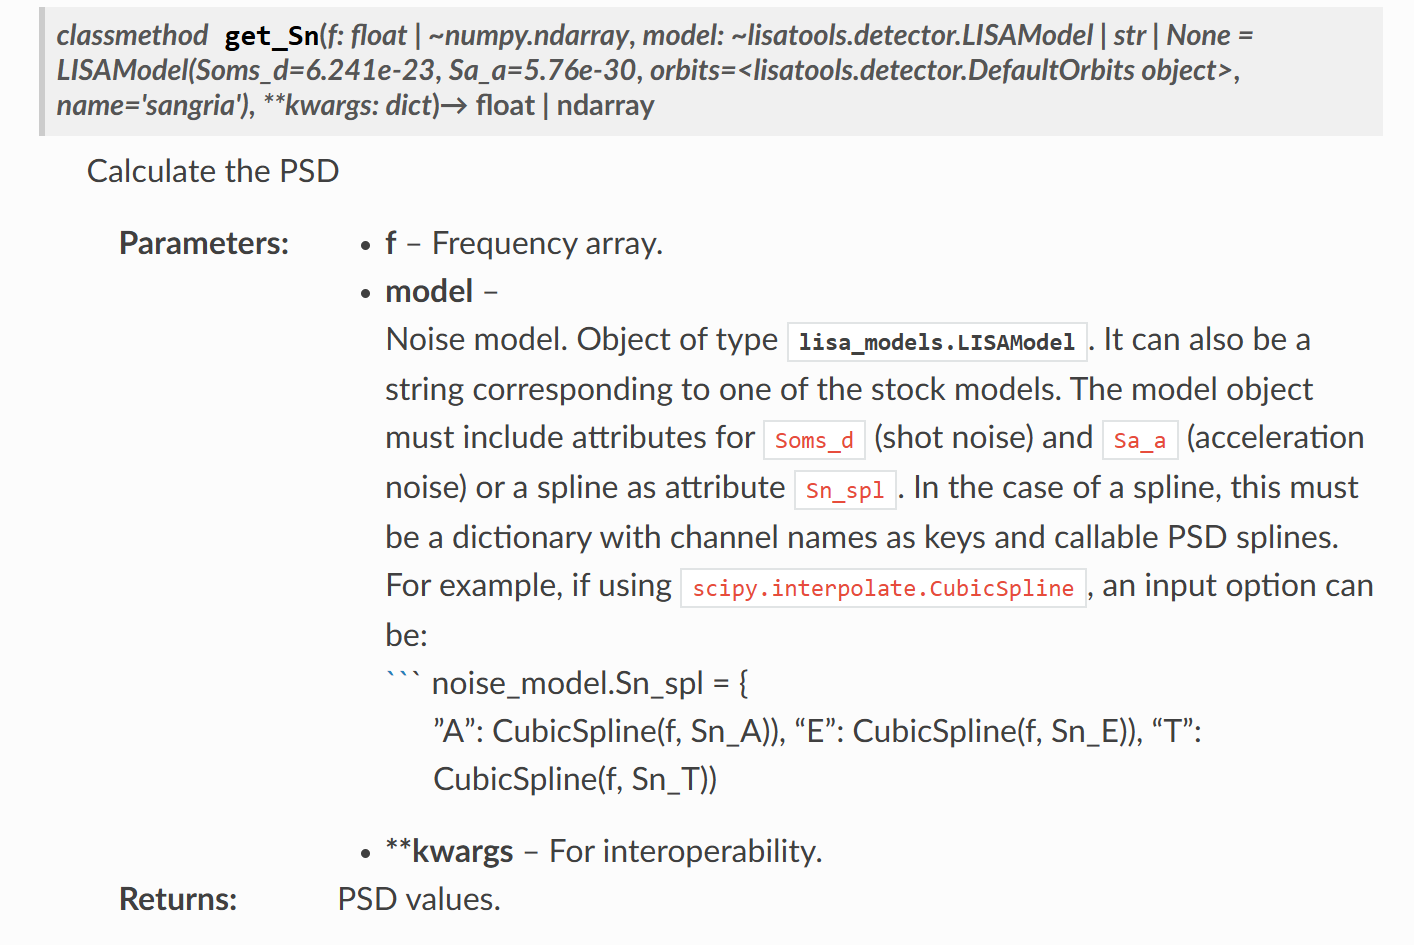
calculate the PSD（其实就是噪声，这个没问题），但是我们看到似乎也没有加随机函数的参数.``**kwargs`` – For interoperability.这代表参数还会传递，这是一个父类。
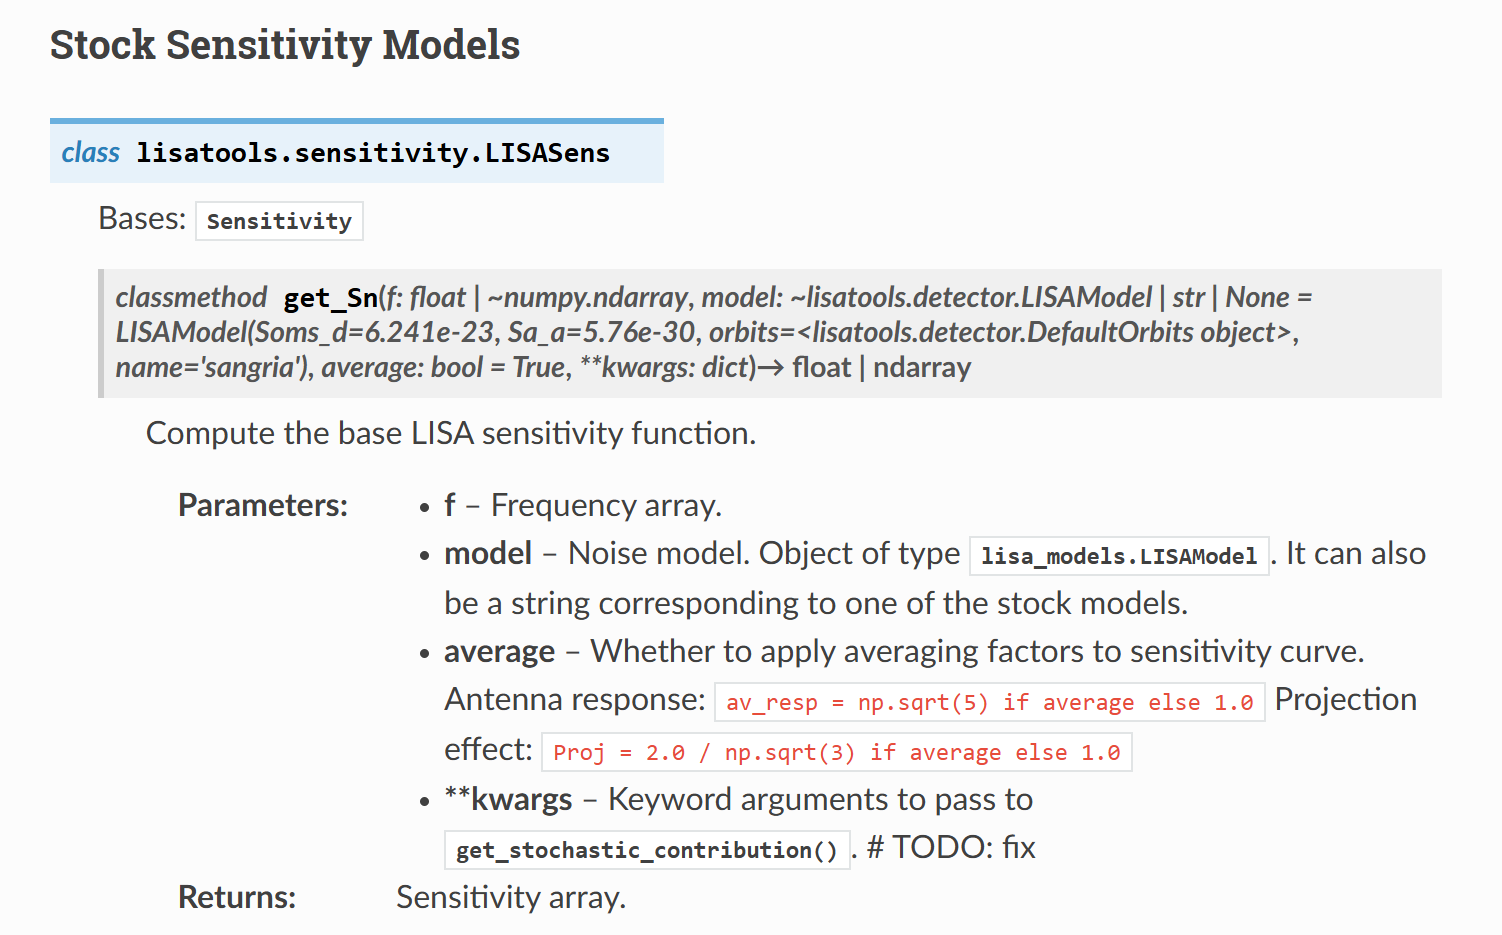
在这个里面，上面的For interoperability，进行了重写，``**kwargs`` – Keyword arguments to pass to ``get_stochastic_contribution()``.
继续传递``get_stochastic_contribution()``.
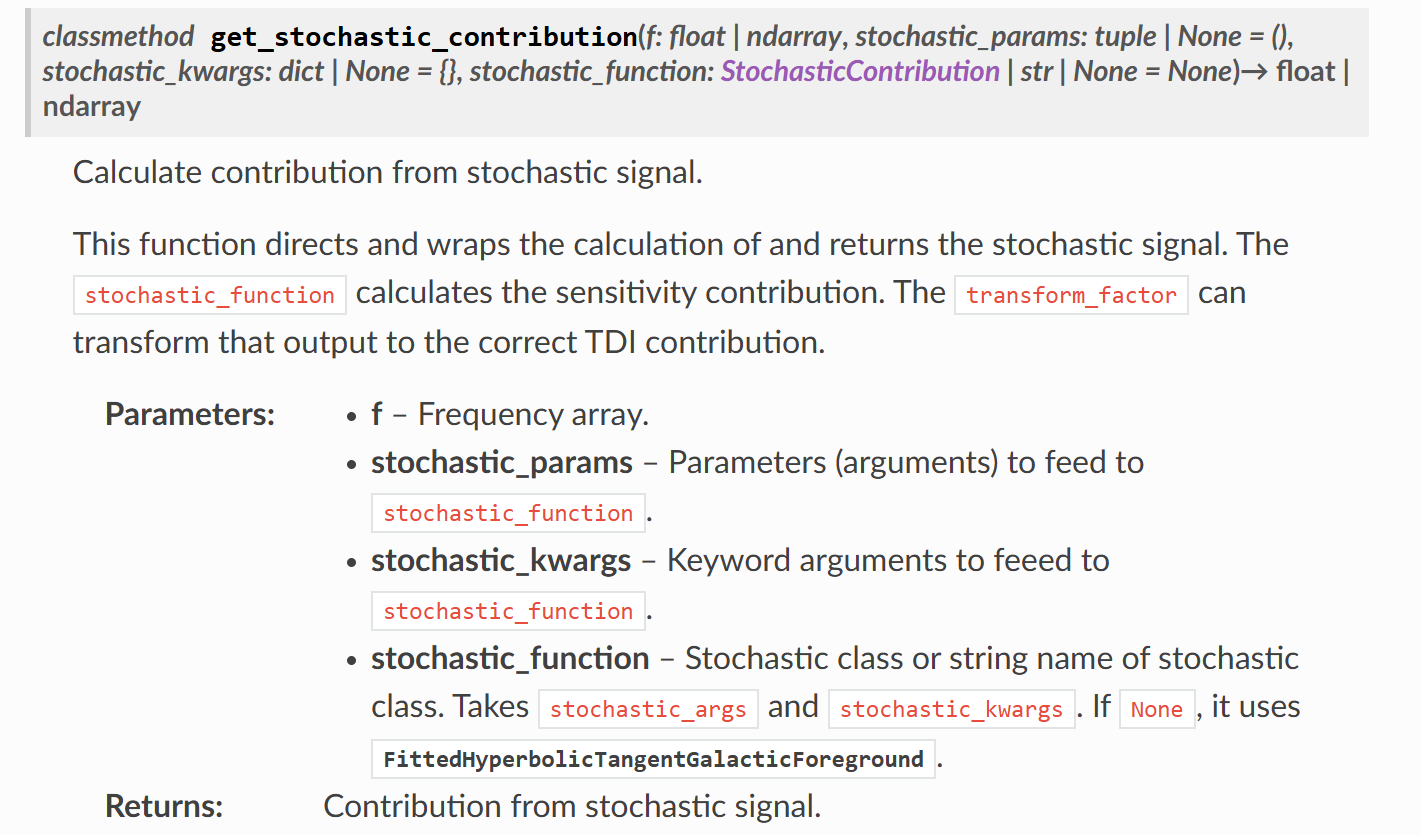
计算随机信号的贡献。这里的$f$和其他的参数并不会变，只要不重新定义，一定是SensitivityMatrix，是传递下来的。

这里解释了为啥要在时间后面加个``,``，这是要将其转换为单元素元组（Single-item Tuple），这个是反馈给随机函数的值。要求是元组。

``stochastic_function`` – Stochastic class or string name of stochastic class. Takes stochastic_args and stochastic_kwargs. If None, it uses ``FittedHyperbolicTangentGalacticForeground``.不给随机函数的名字，默认``FittedHyperbolicTangentGalacticForeground``。我们继续找这个
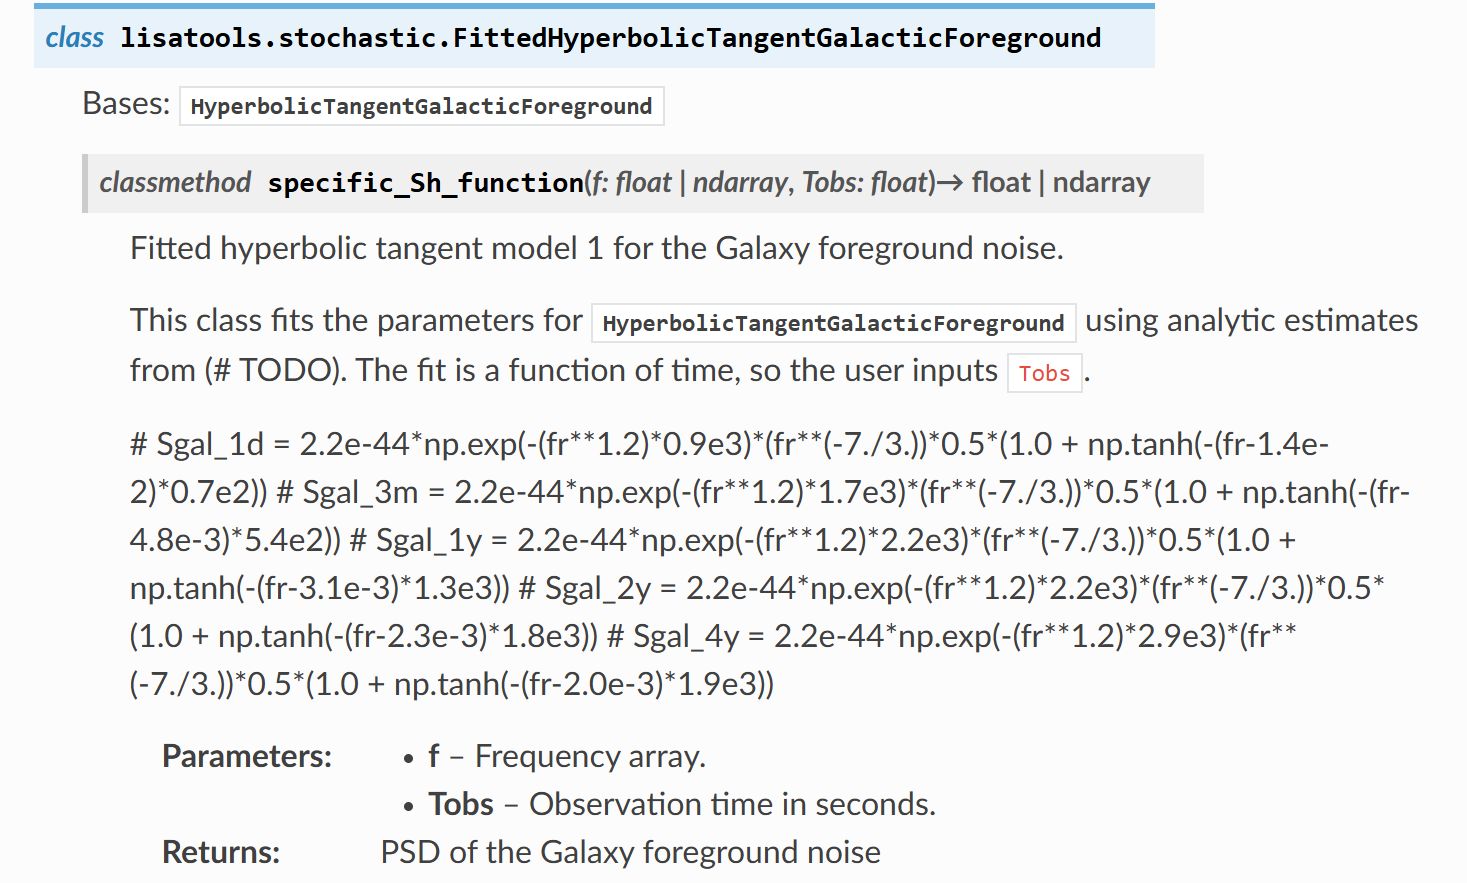
``Tobs`` – Observation time in seconds.
$f$是传递下来的，所以只需要给观测的时间即可。PSD of the Galaxy foreground noise。给出的就是PSD，也就是噪声曲线，也就是灵敏曲线，星系前景背景噪声。就可以给出随机信号的贡献了。最后传回到``SensitivityMatrix``中计算总的灵敏矩阵(其中含有随机背景的噪声)。

sens_mat –Input sensitivity list. The shape of the nested lists should represent the shape of the desired matrix. Each entry in the list must be an array, Sensitivity-derived（sensitivity的衍生） object, or a string corresponding to the Sensitivity object（这个直接看Base即可）.
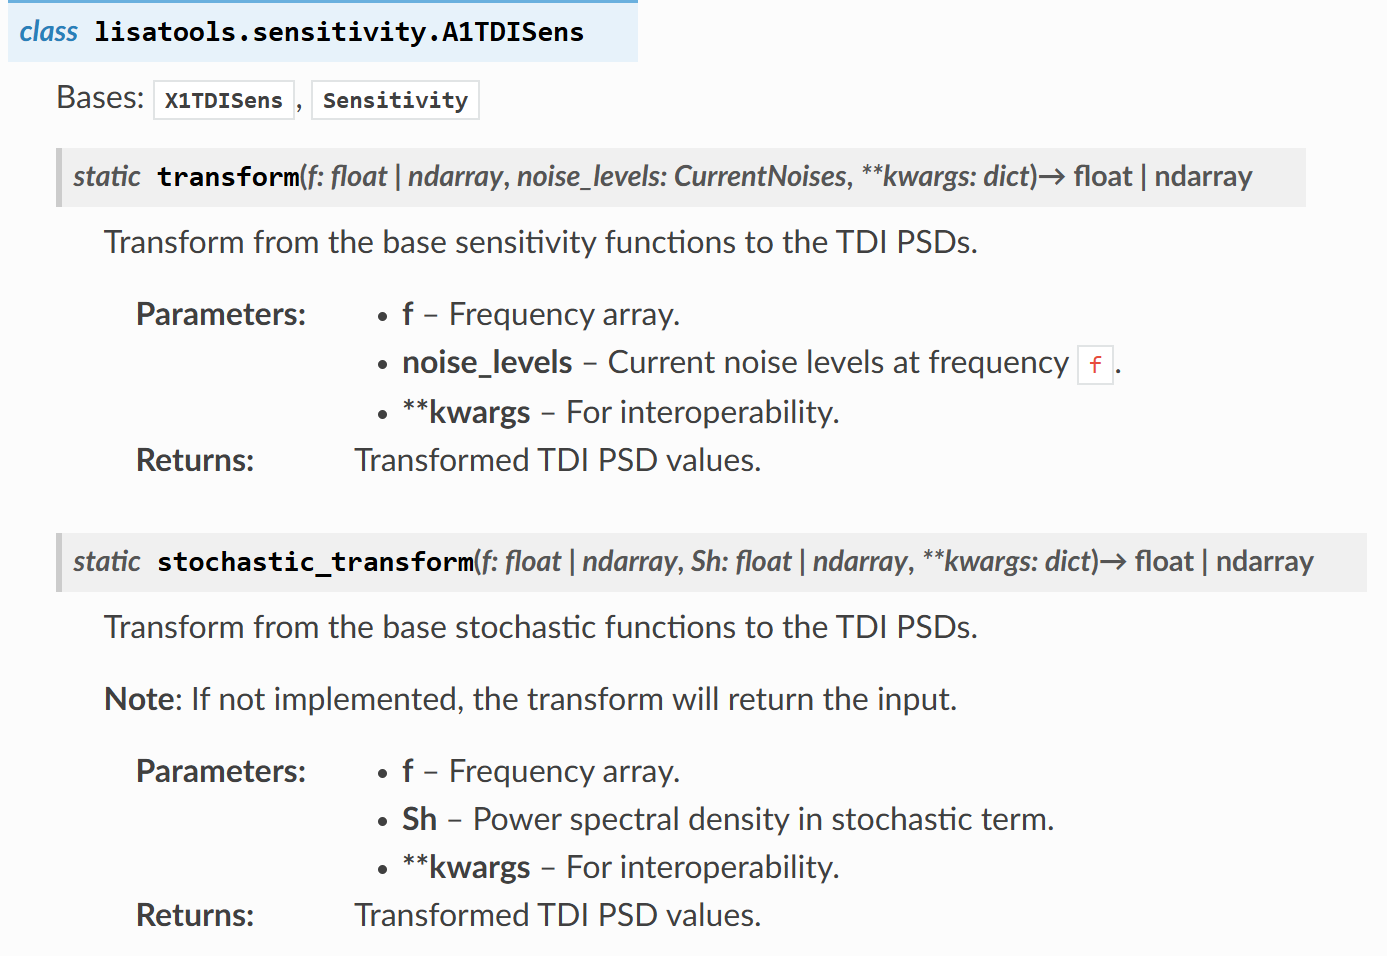
这个写的是给出的变换后，也就是从XYZ变换到A之后的TDI PSD的值（噪声就是灵敏度），完全符合灵敏度的要求。

Plot it with the [loglog](https://mikekatz04.github.io/LISAanalysistools/build/html/user/sensitivity.html#lisatools.sensitivity.SensitivityMatrix.loglog) method of the matrix.

(<Figure size 640x480 with 2 Axes>, array([<Axes: >, <Axes: >], dtype=object))

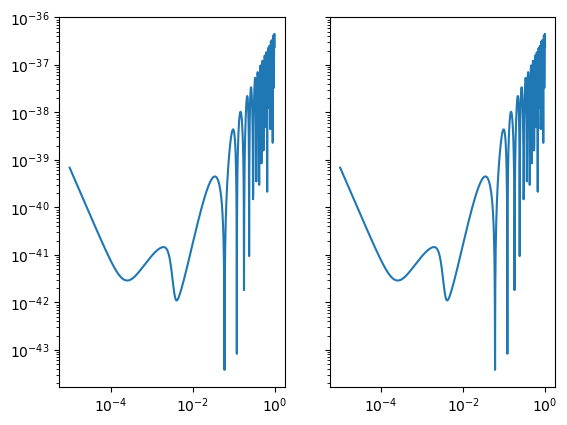

In [12]:
sens_mat.loglog()

这里的loglog在说明书中也有定义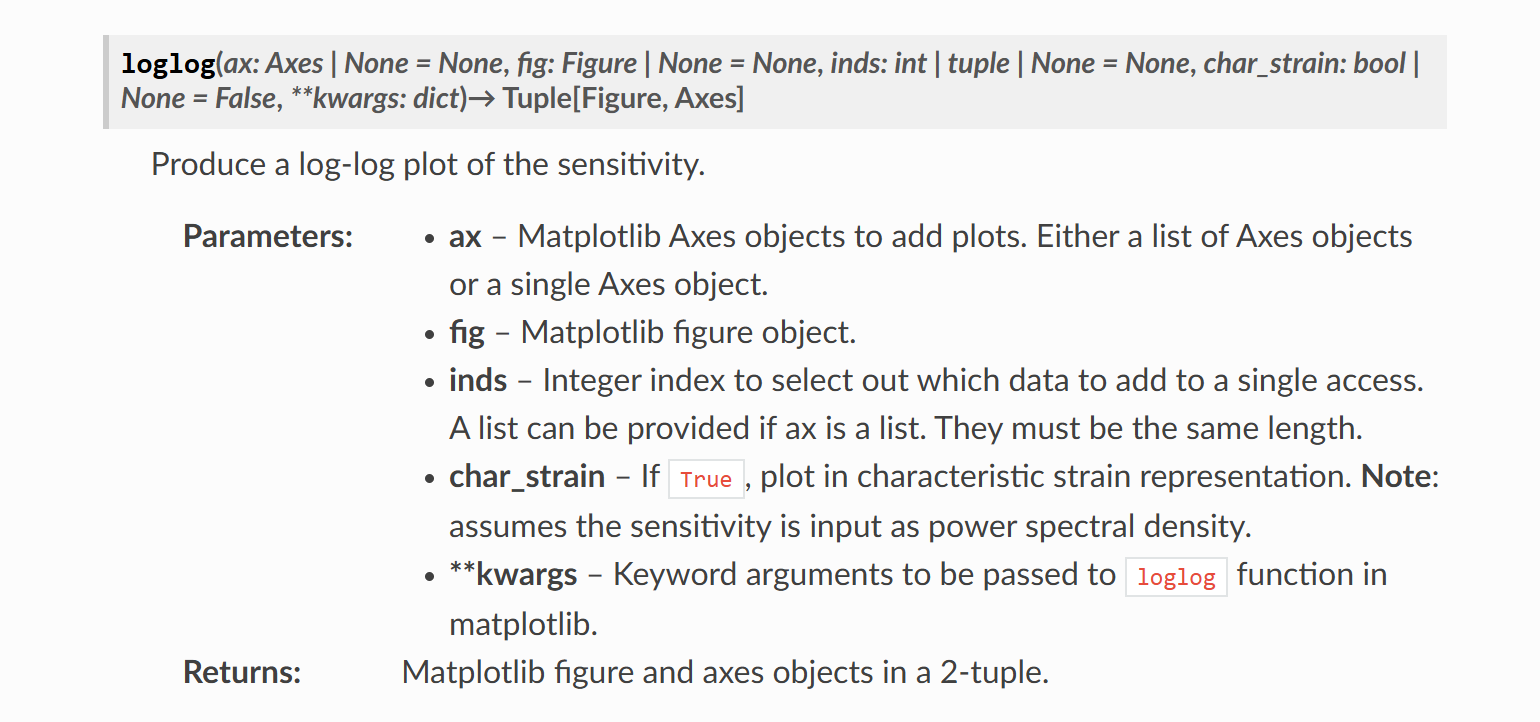

Compare the noise curve with and without foreground confusion noise. And then compare the foreground noise at two different values of the observation time. 

Useful documentation:
* [update_stochastic](https://mikekatz04.github.io/LISAanalysistools/build/html/user/sensitivity.html#lisatools.sensitivity.SensitivityMatrix.update_stochastic)

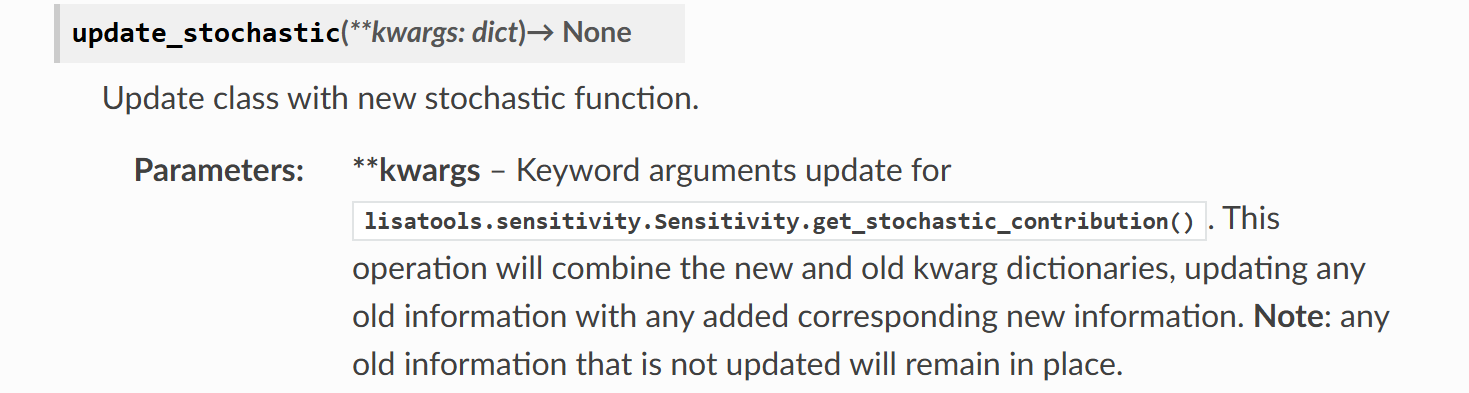

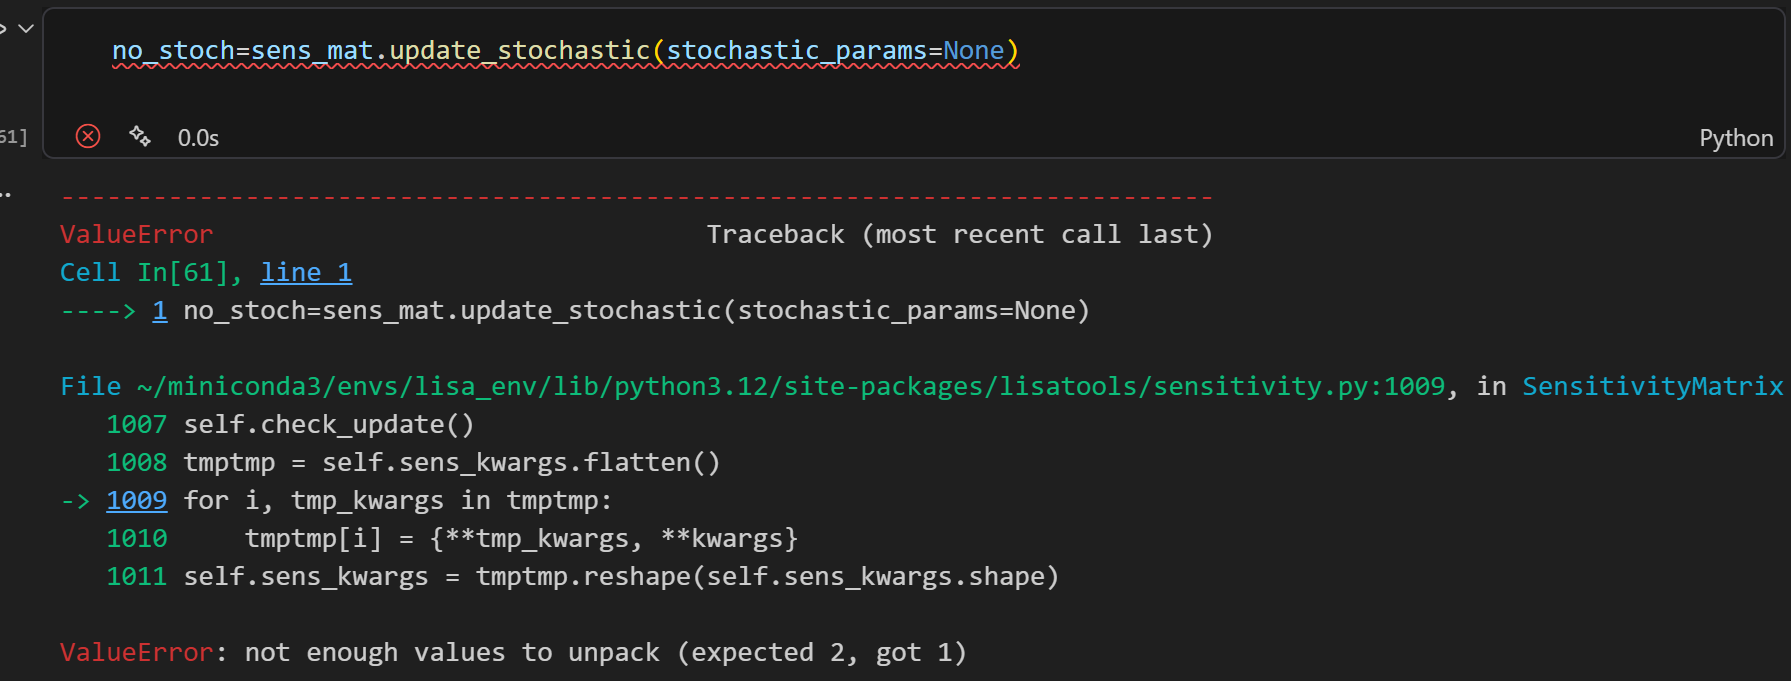
这行代码有错。底层的逻辑有错。
``for i, tmp_kwargs in enumerate(tmptmp):``这样才对。

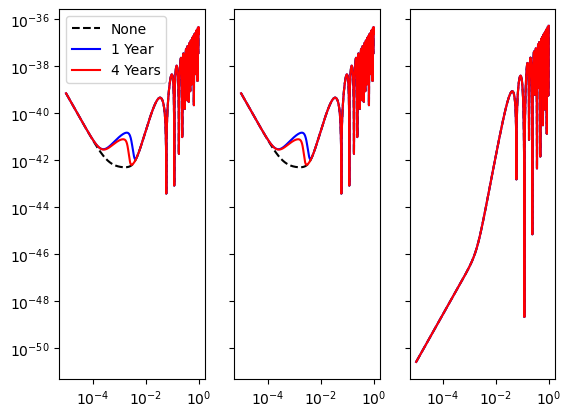

In [13]:
sens_kwargs4 = {"stochastic_params":(4.0 * YRSID_SI,)}
sens_mat4 = SensitivityMatrix(f, [A1TDISens,E1TDISens,T1TDISens], **sens_kwargs4)
sens_kwargs1 = {"stochastic_params":(1.0 * YRSID_SI,)}
sens_mat1 = SensitivityMatrix(f, [A1TDISens,E1TDISens,T1TDISens], **sens_kwargs1)
# 直接不传**sens_keargs即可，就是默认没有随机函数的贡献
sens_mat0 = SensitivityMatrix(f, [A1TDISens,E1TDISens,T1TDISens])


fig, ax = sens_mat0.loglog(label="None", color="black", ls="--")

# 第二步：将 fig 和 ax 传给后续的 loglog，实现曲线叠加
sens_mat1.loglog(fig=fig, ax=ax, label="1 Year", color="blue")
sens_mat4.loglog(fig=fig, ax=ax, label="4 Years", color="red")

ax[0].legend()

### Question

Why does the foreground confusion change over time? What are the broader implications of this on our analysis?

随着时间的积分，则信噪比是提高的，因为前景背景的噪声是有一定的规律的，可以进行剥离，最终得到真正的信号，所以这样的灵敏度随时间提高。需要注意更长时间的信号。

### Task 2: Build a `DataResidualArray` to house and plot data information.

We are going to build a sinusoidal signal for us to do some computations with. We will store it in a [DataResidualArray](https://mikekatz04.github.io/LISAanalysistools/build/html/user/datacontainer.html#lisatools.datacontainer.DataResidualArray). Build a sinusoidal signal with 4 parameters: $A$ (amplitude), $f_0$ (frequency), $\dot{f}_0$ (frequency derivative), and $\phi_0$ (initial phase):

$$ h_1(t) = A\sin{\left(2\pi (f_0 t + \frac{1}{2}\dot{f}_0t^2) + \phi_0\right)} $$
$$ h_2(t) = A\cos{\left(2\pi (f_0 t + \frac{1}{2}\dot{f}_0t^2) + \phi_0\right)} $$

Pick your parameters. Use a reasonable timestep ($\sim10$s) and observation time ($\sim$yr) for LISA. Plot $h_1$ and $h_2$. 

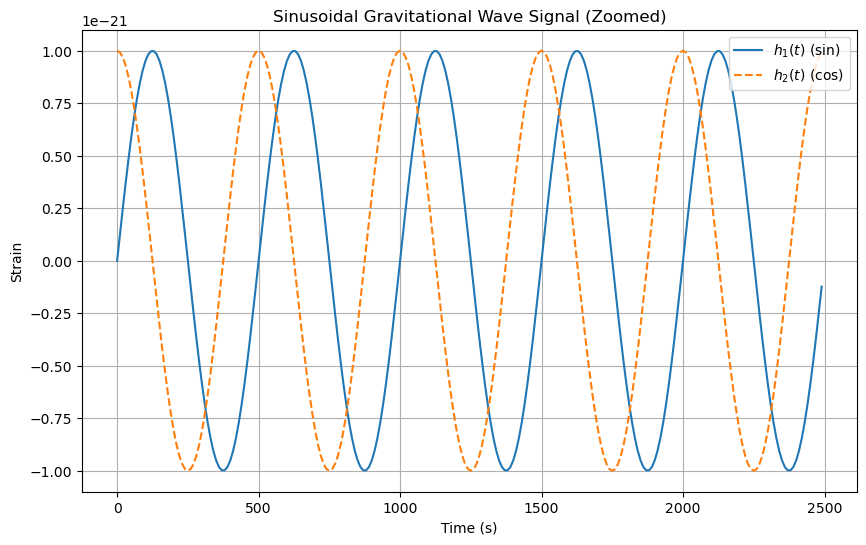

In [14]:
from lisatools.datacontainer import DataResidualArray
# 1. 设置 LISA 相关的参数
dt = 10.0                       # 时间步长 (秒)
Tobs = 365 * 24 * 3600          # 观测时间 (1年，单位秒)
t = np.arange(0, Tobs, dt)      # 时间序列
# 定义信号参数
A = 1e-21                       # 振幅 (典型的引力波应变强度)
f0 = 2e-3                       # 初始频率 (2 mHz, LISA 敏感频段)
f_dot = 1e-10                   # 频率变化率 (Hz/s)
phi0 = 0.0                      # 初始相位
# 2. 生成信号 h1(t) 和 h2(t)
phase = 2 * np.pi * (f0 * t + 0.5 * f_dot * t**2) + phi0
h1 = A * np.sin(phase)
h2 = A * np.cos(phase)
# 3. 绘图
plt.figure(figsize=(10, 6))
zoom_limit = int(5 * (1/f0) / dt)  # 只画前 5 个周期
plt.plot(t[:zoom_limit], h1[:zoom_limit], label='$h_1(t)$ (sin)')
plt.plot(t[:zoom_limit], h2[:zoom_limit], label='$h_2(t)$ (cos)', linestyle='--')
plt.xlabel('Time (s)')
plt.ylabel('Strain')
plt.title('Sinusoidal Gravitational Wave Signal (Zoomed)')
plt.legend()
plt.grid(True)
plt.show()


Now we will add our two channels (h1, h2) into a `DataResidualArray`. 

Useful Documentation:
* [DataResidualArray](https://mikekatz04.github.io/LISAanalysistools/build/html/user/datacontainer.html#lisatools.datacontainer.DataResidualArray)

In [15]:
# useful imports
from lisatools.datacontainer import DataResidualArray

In [16]:
signal_container = DataResidualArray([h1,h2], dt=dt)

Plot the signals with the data residual array plotting functions.

Useful documentation:
* [loglog](https://mikekatz04.github.io/LISAanalysistools/build/html/user/datacontainer.html#lisatools.datacontainer.DataResidualArray.loglog)

(<Figure size 640x480 with 2 Axes>, array([<Axes: >, <Axes: >], dtype=object))

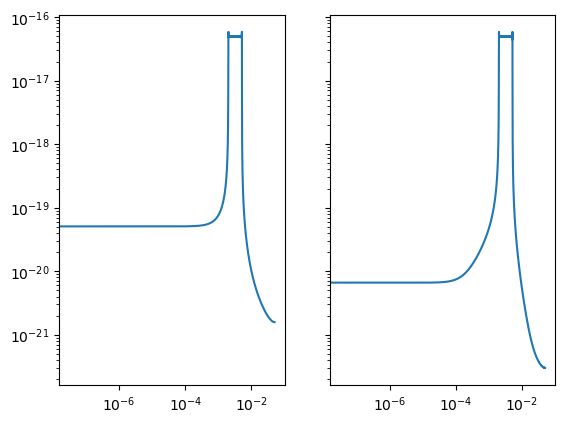

In [17]:
signal_container.loglog()#绘图

### Question 3

When you put in the time-domain signal from above, the `DataResidualArray` class transforms it under the hood. Looking at the output from above, what transform did it do?

Let's take the FFT of our input time-domain dataset with numpy (`np.fft.rfft`) and add this to the above plot. 

当我们将其放入``DataResidualArray``,其自动将其变为了频域空间。FFT变化。

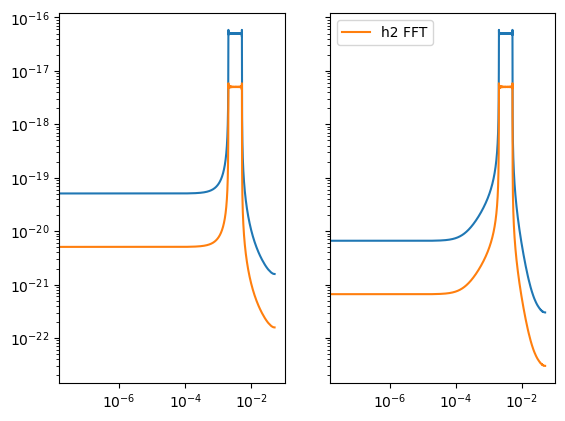

In [18]:
fig, ax = signal_container.loglog()
h1_f = np.abs(np.fft.rfft(h1))
h2_f = np.abs(np.fft.rfft(h2))
ax[0].loglog(signal_container.f_arr, h1_f,label="h1 FFT")
ax[1].loglog(signal_container.f_arr, h2_f,label="h2 FFT")
plt.legend()

What is the factor difference between the FFT we did and the frequency-domain spectra stored in our `DataResidualArray`? Where does this term come from and why is it there? (this is a small detail that is always easy to forget)

手动 FFT (np.fft.rfft): 计算的是一个纯数字的求和：$$H_k = \sum_{j=0}^{N-1} h_j e^{-i 2\pi j k / N}$$这个结果是无量纲的（或者说单位和时间域信号一致），它的数值大小取决于采样点的数量。物理频率域信号 ($\tilde{h}(f)$): 引力波分析中需要的物理量是连续傅里叶变换的近似：$$\tilde{h}(f) \approx \int h(t) e^{-i 2\pi f t} dt \approx \sum h_j e^{-i 2\pi f t_j} \Delta t$$即：$$\tilde{h}(f) = H_{fft} \cdot dt$$

In [19]:
np.abs(signal_container[0]) / h1_f

array([10., 10., 10., ..., 10., 10., 10.], shape=(1576801,))

``signal_container[0]``：对应你传入的第一个信号 h1。

``signal_container[1]``：对应你传入的第二个信号 h2。

## Task 3: Combine into an `AnalysisContainer`.

Now we will use our data and sensitivity information and combine it into an [AnalysisContainer](https://mikekatz04.github.io/LISAanalysistools/build/html/user/datacontainer.html#analysis-container) object. This object helps streamline the analysis by working under the hood properly with different data and sensitivity matrices.

Plot the new setup with both the data and sensitivity information. We will do computations with this object a little later. 

Helpful documentation:
* [AnalysisContainer](https://mikekatz04.github.io/LISAanalysistools/build/html/user/datacontainer.html#analysis-container)
* [AnalysisContainer.loglog](https://mikekatz04.github.io/LISAanalysistools/build/html/user/datacontainer.html#lisatools.analysiscontainer.AnalysisContainer.loglog)

该函数用于组合了敏感性和数据信息的组合容器。

In [20]:
from lisatools.analysiscontainer import AnalysisContainer

(<Figure size 640x480 with 2 Axes>, array([<Axes: >, <Axes: >], dtype=object))

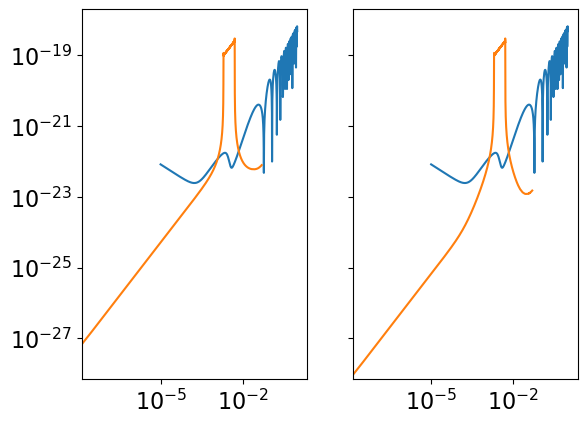

In [21]:
sens_kwargs04 = {"stochastic_params":(1.0 * YRSID_SI,)}
sens_mat04 = SensitivityMatrix(f, [A1TDISens,E1TDISens], **sens_kwargs04)
#sens_mat04.update_frequency_arr(signal_container.f_arr)
analysis = AnalysisContainer(signal_container,sens_mat04)
analysis.loglog()

## Task 4: Compute the inner product.

Now we will inject a signal into the data and calculate the inner product of another signal with that data. We will take `data_res_arr` as the data input. 

Generate a new signal witih a slightly different set of parameters from the injection you chose above. 

In [22]:
A_new = A 
f0_new = f0 
fdot_new = f_dot * (1.100001)
phi0_new = phi0  

In [23]:
phase_new = 2 * np.pi * (f0_new * t + 0.5 * fdot_new * t**2) + phi0
h1_new = A_new * np.sin(phase_new)
h2_new = A_new * np.cos(phase_new)

What is the inner product value of your new signal with the injected data? With numpy calculate the inner product using this equation:

$$ \langle h_1 | h_2 \rangle = 4 \text{Re} \int_{f_\text{min}}^{f_\text{max}}\frac{\tilde{h}_1(f)^*\tilde{h}_2(f)}{S_n(f)}df \ \ .$$


In [33]:
template = DataResidualArray([h1_new, h2_new], dt=dt)
sens_mat04.update_frequency_arr(template.f_arr)
hold_hnew = 4 * template.df * np.real(np.sum(template[:, 1:].conj() * signal_container[:, 1:] / sens_mat04[:, 1:]))
print(hold_hnew)

/home/yudh/miniconda3/envs/lisa_env/lib/python3.12/site-packages/lisatools/detector.py:655: RuntimeWarning: divide by zero encountered in divide
  Sa_a = Sa_a_in * (1.0 + (0.4e-3 / frq) ** 2) * (1.0 + (frq / 8e-3) ** 4)
/home/yudh/miniconda3/envs/lisa_env/lib/python3.12/site-packages/lisatools/detector.py:657: RuntimeWarning: divide by zero encountered in power
  Sa_d = Sa_a * (2.0 * np.pi * frq) ** (-4.0)
/home/yudh/miniconda3/envs/lisa_env/lib/python3.12/site-packages/lisatools/detector.py:659: RuntimeWarning: invalid value encountered in multiply
  Sa_nu = Sa_d * (2.0 * np.pi * frq / C_SI) ** 2
/home/yudh/miniconda3/envs/lisa_env/lib/python3.12/site-packages/lisatools/detector.py:664: RuntimeWarning: divide by zero encountered in divide
  Soms_d = Soms_d_in * (1.0 + (2.0e-3 / f) ** 4)
/home/yudh/miniconda3/envs/lisa_env/lib/python3.12/site-packages/lisatools/detector.py:666: RuntimeWarning: invalid value encountered in multiply
  Soms_nu = Soms_d * (2.0 * np.pi * frq / C_SI) ** 2
/h

15001.050265597753


In [32]:
#template = DataResidualArray([h1_new, h2_new], dt=dt)
#sens_mat.update_frequency_arr(template.f_arr)
hold_hnew01 = 4 * template.df * np.real(np.sum(signal_container[:, 1:].conj() * signal_container[:, 1:] / sens_mat04[:, 1:]))
print(hold_hnew)

31042883.024755683


当信号和信号完全匹配的时候，其SNR^2=31042883,当我们的频率变化了1.000001，如此微小的量级，便会产生SNR^2的差距。这会让MCMC注意到，从而说明我们的参数错了。

In [26]:
template[:,:]

array([[ 1.04769611e-19+0.00000000e+00j,  1.04769611e-19+1.09694481e-25j,
         1.04769611e-19+2.18993083e-25j, ...,
         2.23183215e-21-6.95036002e-27j,  2.23183246e-21-3.56978532e-27j,
         2.23183278e-21+0.00000000e+00j],
       [-9.67435187e-21+0.00000000e+00j, -9.67435247e-21+1.39415424e-24j,
        -9.67435215e-21+2.78779335e-24j, ...,
         9.38959900e-21-1.74550686e-26j,  9.38959841e-21-8.35071898e-27j,
         9.38959808e-21+0.00000000e+00j]], shape=(2, 1576801))

为何要更新频率阵列？

当一个时间序列经过离散傅里叶变换（FFT）变成频域信号时，它的频率网格是被这两个时间参数唯一决定的：频率步长 $df = 1 / T_{\text{obs}}$最大频率（奈奎斯特频率） $f_{\max} = 1 / (2\Delta t)$

对于积分，我们可以用$\Delta f$积分值，进行处理。signal_container[:, 1:]，第一个:，让所有的通道全算上，1：是因为从$f>0Hz$开始，而不是从$f=0Hz$开始进行计算，$f=0Hz$的信号是不存在的。


Now, calculate the inner product using the [inner_product](https://mikekatz04.github.io/LISAanalysistools/build/html/user/datacontainer.html#lisatools.analysiscontainer.AnalysisContainer.inner_product) method in the `AnalysisContainer` class. 

代码有问题，numpy更新了，trapz变为了trapezoid

In [27]:
import numpy as np
np.trapz = np.trapezoid

In [28]:
analysis.template_inner_product(template)

15001.050265635782

The numbers may not match exactly. Under the hood, the inner product function in `lisatools` uses `np.trapz`. If you do a sum, you may get a very small and negligible difference.

Play around with the parameters you chose above. Try to understand how the inner product changes with the parameters you choose (i.e. how far they are from the injection parameters). 

当参数的偏差离得越远，其内积会导致变小。且变小明显。

## Task 5: Compute the signal-to-noise ratio.

There are two signal-to-noise ratios (SNR) that are of interest to LISA folks. One is the optimal SNR ($\rho_\text{opt}$) of a template. This is the maximal SNR a template can achieve with a given noise profile ($h$ is the template):
$$ \rho_\text{opt} = \sqrt{\langle h | h \rangle}\ \ .  $$
In other words, if the injection data is exactly equivalent to the template, it will achieve this SNR. 

Another SNR of interest is the detected snr ($\rho_\text{det}$). It is given by,
$$ \rho_\text{det} = \frac{\langle d | h \rangle}{\sqrt{\langle h | h \rangle}} = \frac{\langle d | h \rangle}{\rho_\text{opt}}\ \ .  $$

Above, you calcualted $\langle d | h \rangle$, now calculate $\langle h | h \rangle$ with numpy array operations and compute the optimal and detected SNR.

In [34]:
hnew_hnew = 4 * template.df * np.real(np.sum(template[:, 1:].conj() * template[:, 1:] / sens_mat04[:, 1:]))
print(hnew_hnew)
print(f"Opt SNR: {np.sqrt(hnew_hnew)}, Det SNR: {hold_hnew / np.sqrt(hnew_hnew)}")

31252829.451974075
Opt SNR: 5590.423011899375, Det SNR: 2.683347974503466


To compute these values with the `AnalysisContainer` object, use the [template_snr](https://mikekatz04.github.io/LISAanalysistools/build/html/user/datacontainer.html#lisatools.analysiscontainer.AnalysisContainer.template_snr) method.

In [35]:
analysis.template_snr(template)


(np.float64(5590.423011899372), np.float64(2.6833479745102697))

可以给出opt_snr和det_snr的结果

### Question

How does changing the parameters of your template affect the optimal SNR and the detected SNR?

## Task 6: Compute the Likelihood. 

The Likelihood used in LISA (and other areas of GWs) is a Gaussian likelihood that replaces the typical $\frac{x - \mu}{\sigma}$ term with the noise-weighted inner product of the residual data with itself: $\langle \vec{d} - \vec{h} | \vec{d} - \vec{h} \rangle$. Let's break that down. 

1) What do we mean when we say residual(残差)? It is the difference between the data and the template.

$$ \vec{r} = \vec{d} - \vec{h} $$

Calculate the residual of the data and the template and store it in a new `DataResidualArray`.

In [37]:
r1 = h1_new - h1
r2 = h2_new - h2
residual = DataResidualArray([r1, r2], dt=dt)


2) Calculate the inner product of the residual with itself. Hint: You can put it in a new `AnalysisContainer` and calculate it directly with that. 

``updata_frequency_arr()``是原地更新，同名的矩阵，而不是可以将其传递和复制给另一个所以``1=2.updata_..``会发现1什么都没有

在Tutorial0中，Class是按照位置赋值的，所以可以不用写``data_res_arr=``，只需要在第一个位置填入对应的值即可。

In [44]:
sens_kwargs01 = {"stochastic_params":(1.0 * YRSID_SI,)}
sens_mat01=SensitivityMatrix(f, [A1TDISens,E1TDISens], **sens_kwargs01)
sens_mat01.update_frequency_arr(residual.f_arr)
residualanalysis=AnalysisContainer(data_res_arr=residual,sens_mat=sens_mat01)
residualanalysis.inner_product()


/home/yudh/miniconda3/envs/lisa_env/lib/python3.12/site-packages/lisatools/detector.py:655: RuntimeWarning: divide by zero encountered in divide
  Sa_a = Sa_a_in * (1.0 + (0.4e-3 / frq) ** 2) * (1.0 + (frq / 8e-3) ** 4)
/home/yudh/miniconda3/envs/lisa_env/lib/python3.12/site-packages/lisatools/detector.py:657: RuntimeWarning: divide by zero encountered in power
  Sa_d = Sa_a * (2.0 * np.pi * frq) ** (-4.0)
/home/yudh/miniconda3/envs/lisa_env/lib/python3.12/site-packages/lisatools/detector.py:659: RuntimeWarning: invalid value encountered in multiply
  Sa_nu = Sa_d * (2.0 * np.pi * frq / C_SI) ** 2
/home/yudh/miniconda3/envs/lisa_env/lib/python3.12/site-packages/lisatools/detector.py:664: RuntimeWarning: divide by zero encountered in divide
  Soms_d = Soms_d_in * (1.0 + (2.0e-3 / f) ** 4)
/home/yudh/miniconda3/envs/lisa_env/lib/python3.12/site-packages/lisatools/detector.py:666: RuntimeWarning: invalid value encountered in multiply
  Soms_nu = Soms_d * (2.0 * np.pi * frq / C_SI) ** 2
/h

62265710.376198456

3) Build the full Likelihood. The Gaussian likelihood is given by,
$$ \mathcal{L} = e^{-\frac{1}{2}\langle \vec{d} - \vec{h} | \vec{d} - \vec{h} \rangle} \ \ . $$

We usually work with the natural log of the Likelihood:
$$ \ln{\mathcal{L}} = -\frac{1}{2}\langle \vec{d} - \vec{h} | \vec{d} - \vec{h} \rangle \ \ . $$

With this in mind. Take the inner product value from above and calculate the Likelihood of this template. 

In [45]:
likelihood = -1/2 * residualanalysis.inner_product()
print(f"Likelihoood: {likelihood}")


Likelihoood: -31132855.188099228


We can also break apart the inner product into separate pieces because the inner product is a linear operation:
$$ \ln{\mathcal{L}} = -\frac{1}{2}\left(\langle \vec{d} | \vec{d}\rangle + \langle \vec{h} | \vec{h}\rangle - 2 \langle \vec{d} | \vec{h}\rangle\right) \ \ . $$

You should see some familiar terms emerging:
* $\langle \vec{h} | \vec{h}\rangle = \rho_\text{opt}^2$
* $\langle \vec{d} | \vec{h}\rangle \sim \rho_\text{det} * \rho_\text{opt}$ (when phase maximized)
* $\langle \vec{d} | \vec{d}\rangle$ is the inner product of the data with itself. In MCMC analysis generally, the $\langle \vec{d} | \vec{d}\rangle$ term will remain constant throughout sampling.
(d是探测器探测到的GWs的真实的信号，而h是模型也就是样板的数据，所以d的内积是不变的。因为是调整参数，使得h改变去追上d的内积。)

You can calculate the Likelihood of a template against the data using the [template_likelihood](https://mikekatz04.github.io/LISAanalysistools/build/html/user/datacontainer.html#lisatools.analysiscontainer.AnalysisContainer.template_likelihood) method in the `AnalysisContainer` class. 

In [46]:
analysis.template_likelihood(template)


np.float64(-31132855.188099224)

### Question:


How does changing the parameters effect the Likelihood? How does that relate to the optimal and detected SNR values? There are two interesting keyword arguments in the [template_likelihood](https://mikekatz04.github.io/LISAanalysistools/build/html/user/datacontainer.html#lisatools.analysiscontainer.AnalysisContainer.template_snr) method: `include_psd_info` and `phase_maximize`. The `phase_maximize` argument can be found for both the Likelihood and SNR computations. Reading the documentation and adding those keyword arguments in, can you figure out what they are doing with these calculations?

似然函数就是一个“惩罚机制”。参数越偏，惩罚越狠；只有当模板参数和真实数据完美对齐时，$\langle \vec{d} | \vec{h}\rangle$ 达到峰值，$\ln{\mathcal{L}}$ 才会达到最大。

在频域里，改变初始相位 $\phi_0$ 等价于给整个信号乘上一个复数常数 $e^{i\phi_0}$。
数学上可以证明，如果我们直接对内积取复数绝对值（模长），即 $|\langle \vec{d} | \vec{h}\rangle|$，这就相当于我们在数学上自动遍历了所有可能的 $\phi_0$ 并且直接锁定了最大值！


``phase_maximize=True``（默认是false） 的作用：
当你开启这个参数，代码底层的计算逻辑会变成提取复数内积的绝对值。
物理意义：它直接在数学上“消灭”了 $\phi_0$ 这个参数！MCMC 再也不用去猜相位了，每次算出来的 Likelihood 都是在当前其他参数下、相位最完美对齐时的极限值。这直接让 MCMC 的搜索维度减一，速度起飞！

``include_psd_info=True``的作用：
如果有一天，你想让 MCMC 不仅去猜引力波的参数，还要去猜探测器当时的仪器噪声有多大（这在 LISA 数据处理里叫 Global Fit 全局拟合），那么 $S_n(f)$ 就变成了一个会变的参数。此时你必须开启这个选项，把那半截数学公式补回来，似然函数才是绝对严谨的。

## Task 7: Add a signal model. 

Now we will add a signal model to our Likelihood class. You can either set it as a keyword argument when instantiating the `AnalysisContainer`. Or you can just set it as an attribute after the fact. 

But first, we need to turn our sinusoidal signal into a function. Build a function that takes our four parameters ($A$, $f_0$, $\dot{f}_0$, and $\phi_0$) and returns a list of `[h1, h2]`. Add the time array as an argument to your generator. So it should have a signature like: `sinusoidal_waveform(A: float, f0: float, fdot0: float, phi0: float, t_arr: np.ndarray)`

In [50]:
def sinusoidal_waveform(A: float, f0: float, fdot0: float, phi0: float, t_arr: np.ndarray):
    phi_t = 2 * np.pi * (f0 * t_arr + 0.5 * fdot0 * t_arr**2) + phi0
    h1 = A * np.cos(phi_t)
    h2 = A * np.sin(phi_t)
    return [h1, h2]

Now add the signal model to our Likelihood class by updating the `signal_gen` attribute. 

In [51]:
analysis.signal_gen = sinusoidal_waveform

Calculate the Likelihood with a new set of parameters. Remember to add `t` as a last argument to your inputs.

Helpful documentation:
* [AnalysisContainer.calculate_signal_likelihood](https://mikekatz04.github.io/LISAanalysistools/build/html/user/datacontainer.html#lisatools.analysiscontainer.AnalysisContainer.calculate_signal_likelihood)

In [52]:
analysis.calculate_signal_likelihood(A*1.01, f0*1.00, f_dot, phi0, t, source_only=True)

np.float64(-31354848.8376176)

需要澄清几个点：
首先产生函数需要我们自己定义呢？
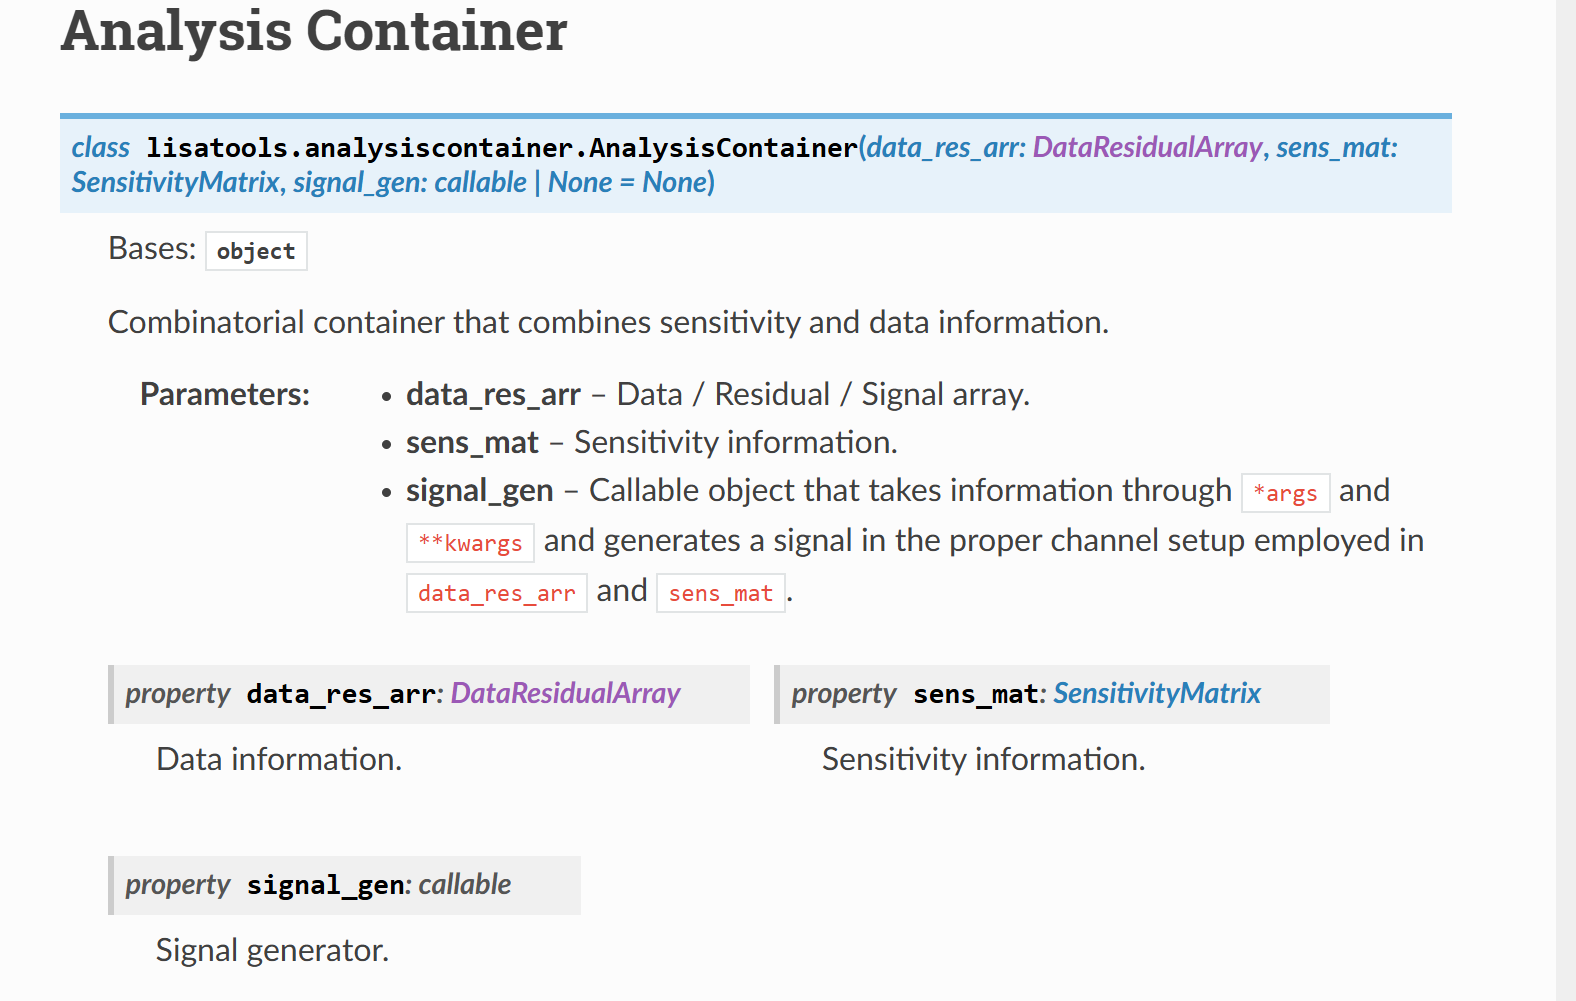
看到``.signal_gen``是callable（可调用的），所以它是根据我们定义的。这一点也很好理解，因为我们的样板信号是任意的不一定是$\sin,\cos$而是可以是任意形状的，这和我们的理论有关。所以需要我们自行定义。

关于``.calculate_signal_likelihood``的解释
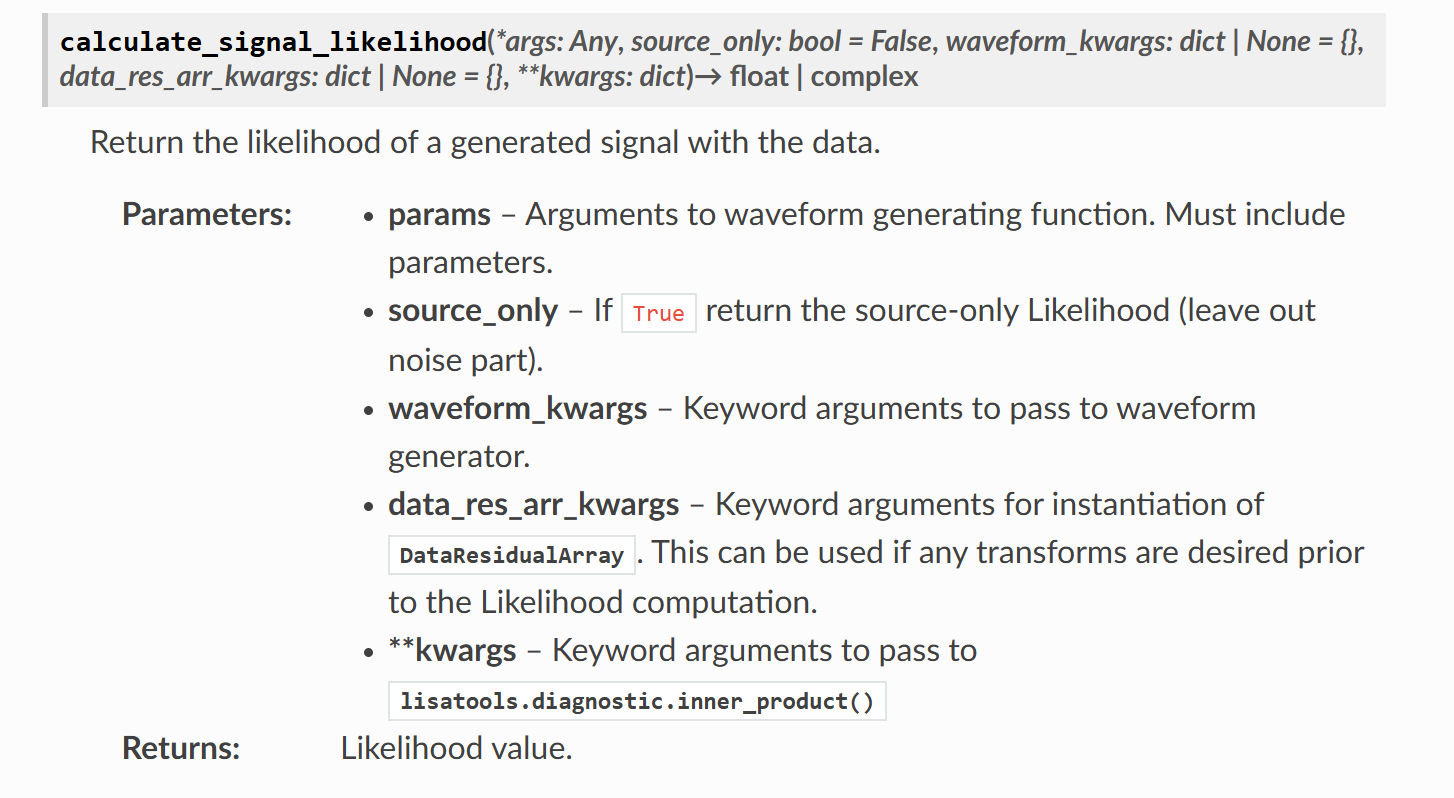
Return the likelihood of a generated signal with the data.返回和数据的似然函数。我们看到params – Arguments to waveform generating function. Must include parameters.（其实这压力的params，更准确的可以写为``*args``）这个会传递给生成函数。

source_only – If True return the source-only Likelihood (leave out noise part).是扔掉噪声项的
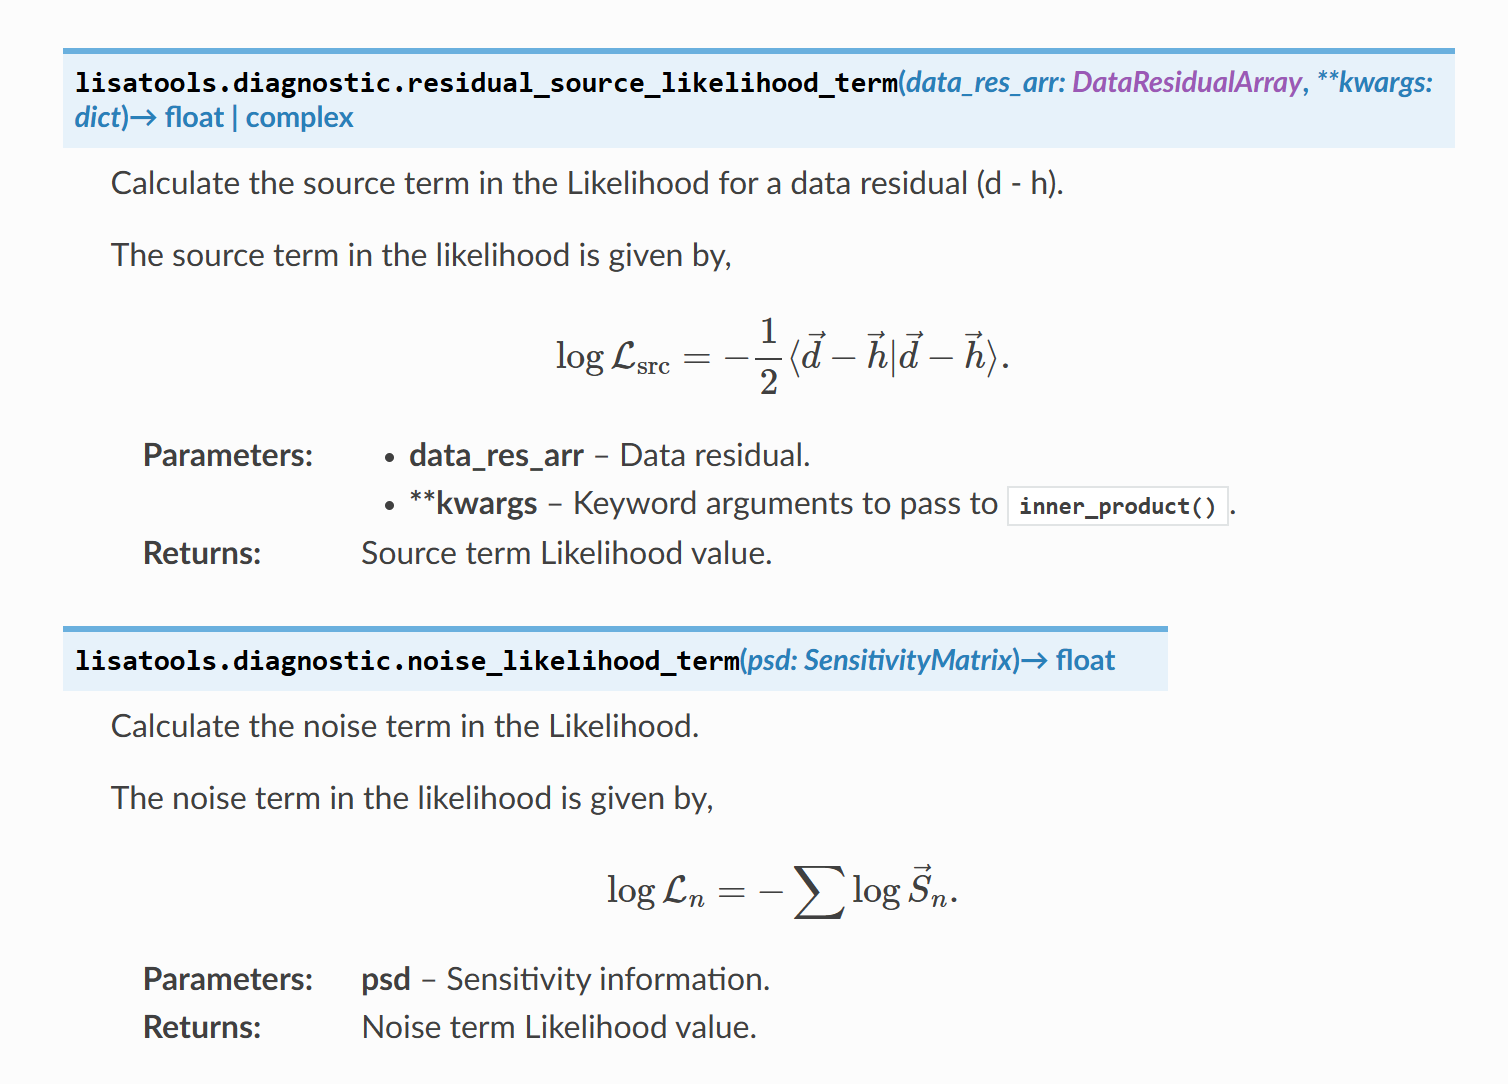

## Extra practice

 Now repeat various parts of the tutorial adjusting the signal or the sensitivity model. Observe how that changes the inner product, SNR, and Likelihood. Having an understanding of these elements is crucial to LISA data analysis!